In [4]:
%load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.poke_detection import *

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/res_study_pilot"

session_index = build_sessions_index(data_dir)

In [9]:
x_test = 0
row = get_session_for_x(session_index, x_test)

fs = row["fs_hz"]
N_cap = int(row["total_captured_sweeps"])

# convert to pandas for plotting (matplotlib-friendly)
pdf = load_session_pandas(row, flip=True)
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap)

Text(0.5, 1.0, 'Raw ADC Signal, CH3, x=+0')

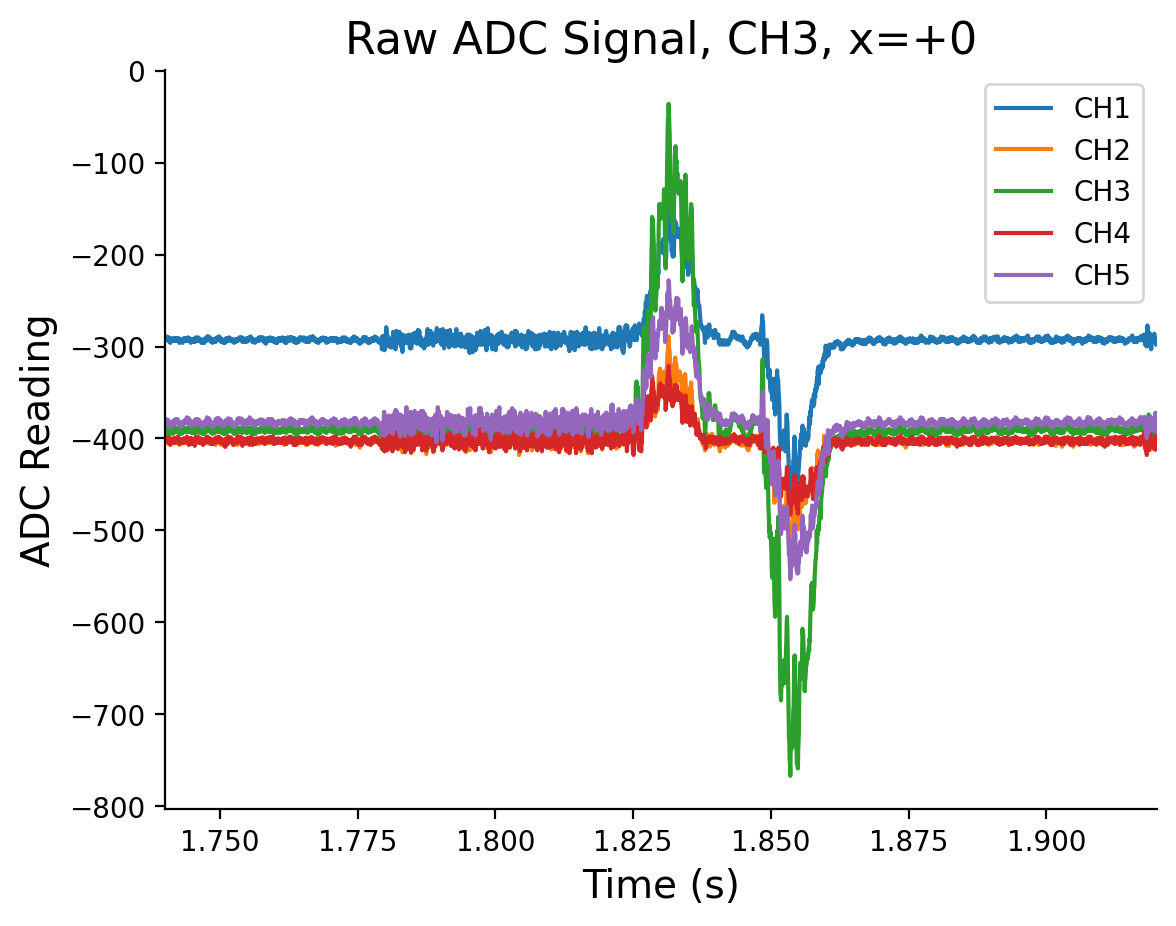

In [10]:
t_adc = np.arange(len(pdf)) / fs
plt.figure(dpi=200)
t0 = 29000
t1 = 32000

for i in range(1, 6):
    plt.plot(t_adc[t0:t1], pdf[f"CH{i}"][t0:t1], label=f"CH{i}")
plt.xlim(t_adc[t0], t_adc[t1])
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("ADC Reading", fontsize=14)
plt.title(f"Raw ADC Signals, x=+{x_test}", fontsize=16)
plt.legend()

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title(f"Raw ADC Signal, CH3, x=+{x_test}", fontsize=16)

In [17]:
all_features = []
xs = [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

for x in xs:
    x_test = x * 100
    row = get_session_for_x(session_index, x_test)

    fs = row["fs_hz"]
    N_cap = int(row["total_captured_sweeps"])

    # convert to pandas for plotting (matplotlib-friendly)
    pdf = load_session_pandas(row, flip=True)

    n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap)

    # validate that the peaks are real
    # plt.figure()
    # plt.plot(mixed_pos)
    # plt.plot(final_peaks, mixed_pos[final_peaks], "rx")
    # plt.title(f"{x_test}, detected {len(final_peaks)} pokes")

    poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=12.0, post_ms=12.0)
    
    features = poke_features_for_session(x_test, poke_windows, fs, t_ref_ms=12.0, pre_ms=3.0, post_ms=8.0)
    all_features.append(features)

features = pd.concat(all_features, ignore_index=True)

In [18]:
suffix = "p2p99"

In [23]:
f_ch2 = features[f'CH2_{suffix}']
f_ch3 = features[f'CH3_{suffix}']
f_ch5 = features[f'CH5_{suffix}']

features['r_pk98_3_5'] = f_ch3 / f_ch5
features['r_pk98_2_3'] = f_ch2 / f_ch3
features['r_pk98_2_5'] = f_ch2 / f_ch5  
features['r_pk98_5_3'] = f_ch5 / f_ch3
features['r_pk98_3_2'] = f_ch3 / f_ch2
features['r_pk98_5_2'] = f_ch5 / f_ch2

features['r_pk98_5_minus_2'] = (f_ch5-f_ch2) / f_ch3


In [24]:
left_locs  = range(0, 4)
right_locs = range(5, 15)

df_left  = features[features['location'].isin(left_locs)]
df_right = features[features['location'].isin(right_locs)]

In [21]:
import matplotlib.transforms as mtransforms

def add_break_marks(ax, side='right', size=10, gap=6, lw=1.2):
    """
    Draw two diagonal break marks on an axis border using pixel units.
    side: 'right' for ax1, 'left' for ax2
    size: length of each slash in pixels
    gap: vertical separation between the two slashes in pixels
    """
    fig = ax.figure
    fig.canvas.draw()  # ensure we have a renderer / correct transforms

    # x position in axes coords where border is
    x_axes = 1.02 if side == 'right' else 0.005

    # Transform from axes coords to display coords (pixels)
    to_disp = ax.transAxes
    to_axes = ax.transAxes.inverted()

    # Two y positions (near bottom and near top) in axes coords
    ys = [0]

    for y_axes in ys:
        # Convert the border point to display coords
        x0, y0 = to_disp.transform((x_axes, y_axes))

        # Build two slashes around that point in display coords
        # Slash 1
        p1 = (x0 - size, y0 - size)
        p2 = (x0 + size, y0 + size)

        # # Convert back to axes coords and plot
        # a1 = to_axes.transform(p1)
        # a2 = to_axes.transform(p2)
        # ax.plot([a1[0], a2[0]], [a1[1], a2[1]],
        #         transform=ax.transAxes, color='k', lw=lw, clip_on=False)

        # Second slash, shifted in display coords (vertical shift)
        p3 = (p1[0], p1[1] + gap)
        p4 = (p2[0], p2[1] + gap)
        a3 = to_axes.transform(p3)
        a4 = to_axes.transform(p4)
        ax.plot([a3[0], a4[0]], [a3[1], a4[1]],
                transform=ax.transAxes, color='k', lw=lw, clip_on=False)


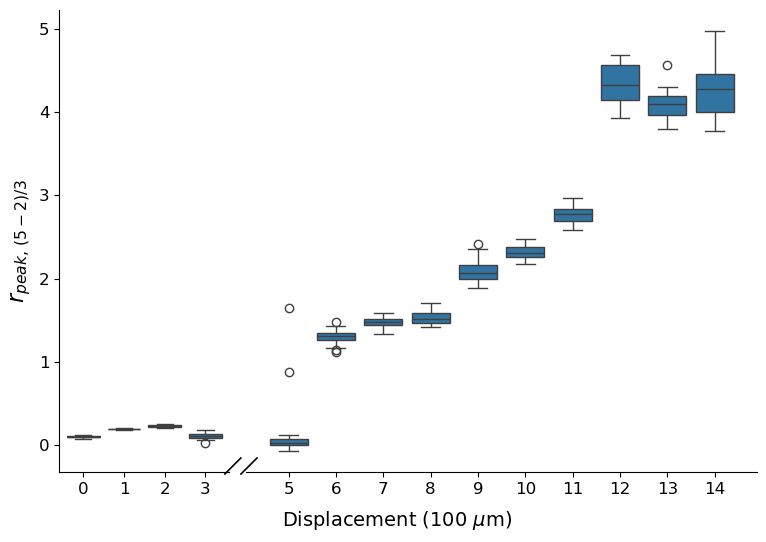

In [30]:
feature_name = 'r_pk98_5_minus_2'
feature_label = r"$r_{{peak, \,(5-2)}/3}$"

f, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(9, 6),
    gridspec_kw={'width_ratios': [1, 3], 'wspace': 0.05}  # smaller gap
)

sns.boxplot(
    data=df_left,
    x='location',
    y=feature_name,
    ax=ax1
)

sns.boxplot(
    data=df_right,
    x='location',
    y=feature_name,
    ax=ax2
)

# ---- spine cleanup ----
for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=12)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)
ax2.tick_params(axis='y', left=False)

# ---- labels ----
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel(feature_label, fontsize=16)

# single centered xlabel
f.supxlabel(r"Displacement (100 $\mu$m)", fontsize=14)

# add break marks
add_break_marks(ax1, side='right', size=8, gap=6, lw=1.2)
add_break_marks(ax2, side='left',  size=8, gap=6, lw=1.2)


In [22]:
from scipy.stats import ttest_ind
def welch_test(df, loc1, loc2):
    x = df[df['location'] == loc1]['r_pk98_5_3']
    y = df[df['location'] == loc2]['r_pk98_5_3']
    t, p = ttest_ind(x, y, equal_var=False)
    return t, p

In [23]:
pairs = [
    (0, 2),
    (1, 3),
    (3, 5),
    (5, 7),
    (6, 8),
    (7, 9),
    (8, 10),
    (9, 11),
    (10, 12),
    (11, 13),
    (12, 14),
]

results = []

for a, b in pairs:
    t, p = welch_test(features, a, b)
    results.append((a, b, t, p))

for a, b, t, p in results:
    print(f"{a:4d} vs {b:4d} µm | t = {t:6.2f} | p = {p:.3e}, significant: {p < 0.05}")

   0 vs    2 µm | t = -11.96 | p = 9.730e-14, significant: True
   1 vs    3 µm | t = -12.56 | p = 2.058e-16, significant: True
   3 vs    5 µm | t = -19.31 | p = 1.701e-22, significant: True
   5 vs    7 µm | t = -65.47 | p = 9.417e-56, significant: True
   6 vs    8 µm | t = -18.81 | p = 1.823e-25, significant: True
   7 vs    9 µm | t = -37.69 | p = 2.044e-33, significant: True
   8 vs   10 µm | t = -38.59 | p = 3.602e-40, significant: True
   9 vs   11 µm | t = -19.09 | p = 9.776e-26, significant: True
  10 vs   12 µm | t = -27.99 | p = 4.104e-25, significant: True
  11 vs   13 µm | t = -27.48 | p = 8.371e-34, significant: True
  12 vs   14 µm | t =   0.88 | p = 3.804e-01, significant: False


In [24]:
len(pairs)

11

In [25]:
x_test = 100
row = get_session_for_x(session_index, x_test)

fs = row["fs_hz"]
N_cap = int(row["total_captured_sweeps"])

# convert to pandas for plotting (matplotlib-friendly)
pdf = load_session_pandas(row)
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap)

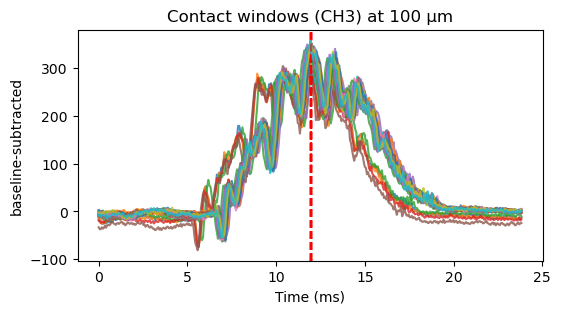

In [26]:
poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=12.0, post_ms=12.0)
plot_poke_windows(poke_windows, fs, ch="CH3")
# plt.title(f"Contact windows (CH5) at 1500 µm")

In [27]:
CHS = ["CH1","CH2","CH3","CH4","CH5"]

def robust_p2p(x, lo=1, hi=99):
    return float(np.percentile(x, hi) - np.percentile(x, lo))

def poke_features_from_window_robust(win, fs, t_ref_ms=12.0, pre_ms=3.0, post_ms=8.0):
    i_ref = int((t_ref_ms/1000.0) * fs)
    i0 = max(0, i_ref - int((pre_ms/1000.0)*fs))
    i1 = min(len(win), i_ref + int((post_ms/1000.0)*fs))

    feats = {}
    pk_list = []

    for ch in CHS:
        x = win[ch].iloc[i0:i1].to_numpy(dtype=float)

        pk98 = float(np.percentile(x, 98))               # robust peak
        p2p = robust_p2p(x, lo=1, hi=99)                 # robust peak-to-peak
        eng = float(np.mean(x*x))                        # mean energy (scale-invariant to window length)
        pos_area = float(np.mean(np.maximum(0.0, x)))    # mean positive area

        feats[f"{ch}_pk98"] = pk98
        feats[f"{ch}_p2p99"] = p2p
        feats[f"{ch}_eng"] = eng
        feats[f"{ch}_posmean"] = pos_area

        pk_list.append(pk98)

    pk = np.array(pk_list)
    s = float(pk.sum()) + 1e-12
    prof = pk / s
    for i, ch in enumerate(CHS):
        feats[f"{ch}_pk98_norm"] = float(prof[i])

    return feats

import pandas as pd
def poke_features_for_session(x, pokes, fs, t_ref_ms=12.0, pre_ms=3.0, post_ms=8.0):
    feature_list = []
    for p in pokes:
        feats = poke_features_from_window_robust(p["window"], fs, t_ref_ms, pre_ms, post_ms)
        feats["location"] = x
        feature_list.append(feats)
    return pd.DataFrame(feature_list)

In [28]:
features = poke_features_for_session(x_test, poke_windows, fs, t_ref_ms=12.0, pre_ms=3.0, post_ms=8.0)

In [29]:
pk98_cols = [c for c in features.columns if c.endswith('_pk98')]
pk98 = features[pk98_cols]

pk98_long = pk98.melt(
    var_name='channel',
    value_name='pk98'
)

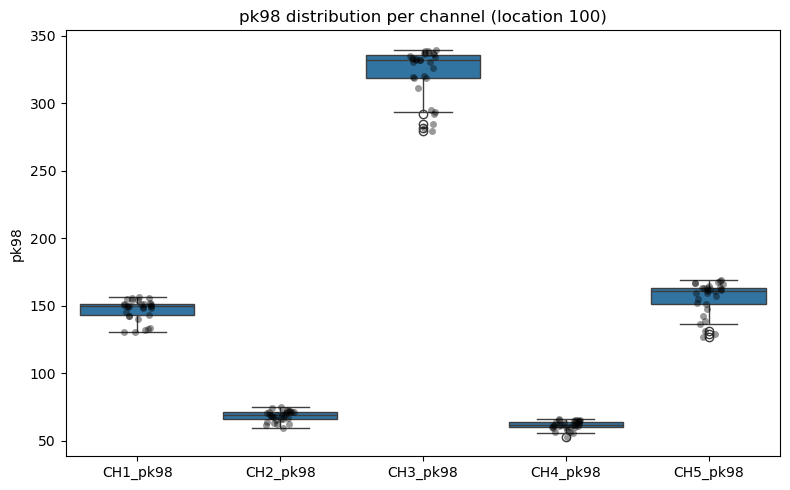

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pk98_long, x='channel', y='pk98')
sns.stripplot(
    data=pk98_long,
    x='channel',
    y='pk98',
    color='black',
    alpha=0.4,
    jitter=True
)

plt.title(f'pk98 distribution per channel (location {x_test})')
plt.ylabel('pk98')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [94]:
features['r_pk98_3_5'] = features['CH3_pk98'] / features['CH5_pk98']
features['r_pk98_3_2'] = features['CH3_pk98'] / features['CH2_pk98']

<Axes: xlabel='location', ylabel='y_pk98'>

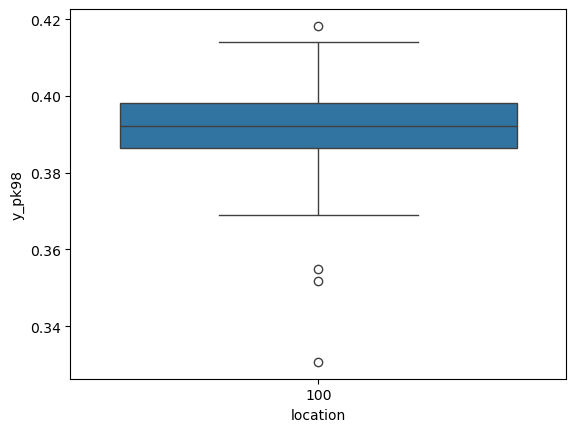

In [98]:
sns.boxplot(
    data=features,
    x='location',
    y='y_pk98'
)